In [92]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

df = pd.read_csv('../../Our Datasets/features_sample_match_new.csv')

start_types_wants = ['pass_interception', 'recovery']

df = df[df['start_type'].isin(start_types_wants)]

df['is_drawing'] = np.where(df['game_state'] == 'drawing', 1, 0)

df['is_middle_third'] = np.where(df['third_start'] == 'middle', 1, 0)

df = df.loc[df['team_out_of_possession_phase_type'] != 'defending_direct']

df['team_out_of_possession_phase_type'] = (
    df['team_out_of_possession_phase_type']
        .replace({
            'defending_set_play': 'set_play',
            'defending_quick_break': 'transition/quick_break',
            'defending_transition': 'transition/quick_break',
            'chaotic': 'chaotic/disruption',
            'disruption': 'chaotic/disruption'
        })
)

df = df.loc[df['team_out_of_possession_phase_type'] != 'set_play']


# dropping irrelevant columns
cols_to_drop = ['start_type', 'end_type', 'error', 
                'dist_to_near_goal', 'dist_to_far_goal', 'third_end', 'game_state', 'n_passing_options_dangerous_not_difficult', 'third_start',
                'n_forward_options', 'd_nearest_opp', 'd_nearest_team', 'mean_team_dist', 'n_opp_within5', 'max_player_targeted_xthreat']

df = df.drop(columns=cols_to_drop)

target_col = "player_targeted_dangerous"
df = df[df[target_col].notna()]

df = df.drop_duplicates(subset=['match_id', 'frame_start', 'frame_end'])

og_df = df.copy()

og_df["row_index"] = og_df.index

classifiers_cols_to_drop = ['Unique ID', 'event_index', 'frame_start', 'frame_end', 'event_row_index', 'source_file', 'rec_player_id', 
                            'rec_team_short', 'rec_team_id']

df = df.drop(columns=classifiers_cols_to_drop)


In [93]:
df = pd.get_dummies(df, columns=["team_out_of_possession_phase_type"], prefix="oop_phase", drop_first=False)

In [94]:
df['match_id'].unique()

array([1886347., 1899585., 1925299., 1953632., 1996435., 2006229.,
       2011166., 2013725., 2015213., 2017461.])

### Dangerous means if the probability of a goal being scored in the next 10 seconds (xthreat) is greater than 0.02

In [95]:
test_match_ids = [1886347, 1899585]

df_model = df.copy()
df_model["row_index"] = df_model.index

# Target
y = df_model["player_targeted_dangerous"].astype(int)

# Features
X = df_model.drop(columns=["player_targeted_dangerous"])

# ---- Build mask from the original dataframe (safest) ----
is_test = df_model["match_id"].isin(test_match_ids)

# ---- Split ----
X_test  = X[is_test].copy()
y_test  = y[is_test].copy()
row_test = df_model.loc[is_test, "row_index"].copy()

X_train = X[~is_test].copy()
y_train = y[~is_test].copy()
row_train = df_model.loc[~is_test, "row_index"].copy()

# ---- NOW drop match_id from both splits ----
X_train = X_train.drop(columns=["match_id"])
X_test  = X_test.drop(columns=["match_id"])

total_rows = len(df_model)

print(f"Train rows: {len(X_train)}  ({len(X_train)/total_rows*100:.2f}%)")
print(f"Test rows : {len(X_test)}   ({len(X_test)/total_rows*100:.2f}%)")


Train rows: 500  (80.39%)
Test rows : 122   (19.61%)


In [96]:
X_test

,dist_to_attacking_goal,is_drawing,is_middle_third,oop_phase_chaotic/disruption,oop_phase_high_block,oop_phase_low_block,oop_phase_medium_block,oop_phase_transition/quick_break,row_index
0,99.575170,1,0,False,True,False,False,False,0
3,34.427403,1,0,True,False,False,False,False,3
14,51.188596,1,1,True,False,False,False,False,14
19,47.054798,1,1,True,False,False,False,False,19
20,72.213891,1,1,False,False,False,True,False,20
...,...,...,...,...,...,...,...,...,...
5357,73.374887,0,0,True,False,False,False,False,5357
5359,46.164589,0,1,True,False,False,False,False,5359
5362,39.101266,0,0,True,False,False,False,False,5362
5365,82.264328,0,0,True,False,False,False,False,5365


In [97]:
rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [5, 10, None],
    "min_samples_leaf": [2, 5, 10],
    "max_features": [0.3, 0.5, 1]
}

rf_grid = GridSearchCV(
    rf_base,
    rf_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=2
)

rf_grid.fit(X_train, y_train)

print("✅ Best RF Params:", rf_grid.best_params_)
print("✅ Best RF CV AUC:", rf_grid.best_score_)

best_rf = rf_grid.best_estimator_


Fitting 5 folds for each of 81 candidates, totalling 405 fits
✅ Best RF Params: {'max_depth': None, 'max_features': 1, 'min_samples_leaf': 10, 'n_estimators': 100}
✅ Best RF CV AUC: 0.6917060696999697


In [98]:
pos = y_train.sum()
neg = (y_train == 0).sum()
scale = neg / pos

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale,
    subsample=0.8
)

xgb_param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [2, 3, 4, None],
    "learning_rate": [0.01, 0.05, .1],
    "min_child_weight": [5, 10, 20]
}

xgb_grid = GridSearchCV(
    xgb_base,
    xgb_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=2
)


xgb_grid.fit(X_train, y_train)

print("✅ Best XGB Params:", xgb_grid.best_params_)
print("✅ Best XGB CV AUC:", xgb_grid.best_score_)

best_xgb = xgb_grid.best_estimator_


Fitting 5 folds for each of 108 candidates, totalling 540 fits
✅ Best XGB Params: {'learning_rate': 0.01, 'max_depth': 2, 'min_child_weight': 5, 'n_estimators': 100}
✅ Best XGB CV AUC: 0.6391802364353876


In [99]:
logreg_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",
        random_state=42
    ))
])

param_grid = [
    # L1 penalty
    {
        "clf__solver": ["liblinear", "saga"],
        "clf__penalty": ["l1"],
        "clf__C": [0.01, 0.1, 1, 10],
        "clf__max_iter": [200, 500, 1000]
    },

    # L2 penalty
    {
        "clf__solver": ["liblinear", "lbfgs", "saga"],
        "clf__penalty": ["l2"],
        "clf__C": [0.01, 0.1, 1, 10],
        "clf__max_iter": [200, 500, 1000]
    },

    # No regularization
    {
        "clf__solver": ["lbfgs", "newton-cg", "saga"],
        "clf__penalty": [None],
        "clf__max_iter": [200, 500, 1000]
    }
]

grid = GridSearchCV(
    estimator=logreg_pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print("✅ Best params:")
print(grid.best_params_)

print("✅ Best CV ROC-AUC:")
print(grid.best_score_)

best_log_reg = grid.best_estimator_


Fitting 5 folds for each of 69 candidates, totalling 345 fits
✅ Best params:
{'clf__max_iter': 200, 'clf__penalty': None, 'clf__solver': 'lbfgs'}
✅ Best CV ROC-AUC:
0.7553865708274895


In [100]:
def evaluate_classifier(model, name):
    pred_test = model.predict(X_test)
    pred_proba = model.predict_proba(X_test)[:, 1]

    print(f"\n📌 {name} Performance")
    print("Accuracy:", accuracy_score(y_test, pred_test))
    print("F1 Score:", f1_score(y_test, pred_test))
    print("ROC-AUC:", roc_auc_score(y_test, pred_proba))
    print("\nClassification Report:\n", classification_report(y_test, pred_test))

evaluate_classifier(best_rf, "Random Forest Classifier")
evaluate_classifier(best_xgb, "XGBoost Classifier")
evaluate_classifier(best_log_reg, "Logistic Regression")


📌 Random Forest Classifier Performance
Accuracy: 0.5901639344262295
F1 Score: 0.45652173913043476
ROC-AUC: 0.6936188811188811

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.65      0.67        78
           1       0.44      0.48      0.46        44

    accuracy                           0.59       122
   macro avg       0.56      0.57      0.56       122
weighted avg       0.60      0.59      0.59       122


📌 XGBoost Classifier Performance
Accuracy: 0.6147540983606558
F1 Score: 0.41975308641975306
ROC-AUC: 0.7115384615384616

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.74      0.71        78
           1       0.46      0.39      0.42        44

    accuracy                           0.61       122
   macro avg       0.57      0.56      0.57       122
weighted avg       0.60      0.61      0.61       122


📌 Logistic Regression Performance
Accuracy: 0.6

In [101]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_gradient_bars(df, value_col, title, cmap="Blues"):
    """
    df: dataframe with 'feature' and value_col
    value_col: column with numeric values (importance, coef, etc.)
    cmap: any matplotlib colormap
    """
    df = df.sort_values(value_col, ascending=True)

    values = df[value_col].values
    features = df["feature"].values

    # Normalize values to [0,1]
    norm = (values - values.min()) / (values.max() - values.min() + 1e-9)

    # Create colors from colormap
    colors = plt.cm.get_cmap(cmap)(norm)

    plt.figure(figsize=(10, max(4, len(df) * 0.4)))
    plt.barh(features, values, color=colors)
    plt.title(title)
    plt.xlabel(value_col)
    plt.tight_layout()
    plt.show()


C:\Users\navee\AppData\Local\Temp\ipykernel_30860\796877662.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap)(norm)


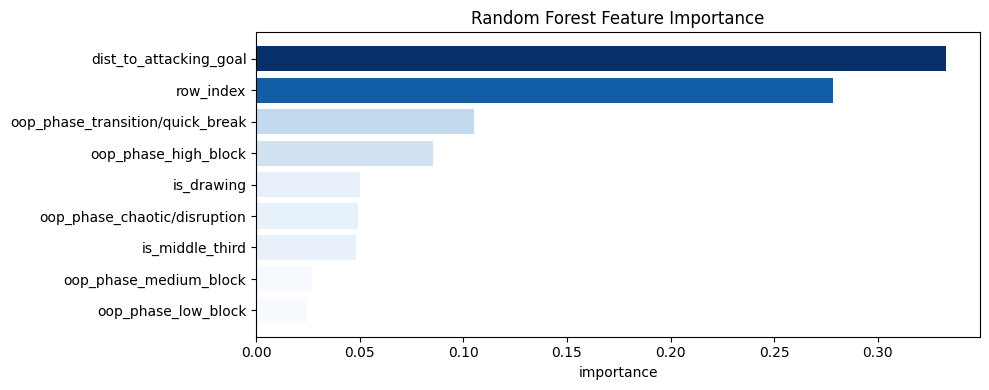

In [102]:
best_rf = rf_grid.best_estimator_

rf_importance = pd.DataFrame({
    "feature": X_test.columns,
    "importance": best_rf.feature_importances_
}).sort_values("importance", ascending=False)

plot_gradient_bars(rf_importance, "importance", "Random Forest Feature Importance", cmap="Blues")


C:\Users\navee\AppData\Local\Temp\ipykernel_30860\796877662.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap)(norm)


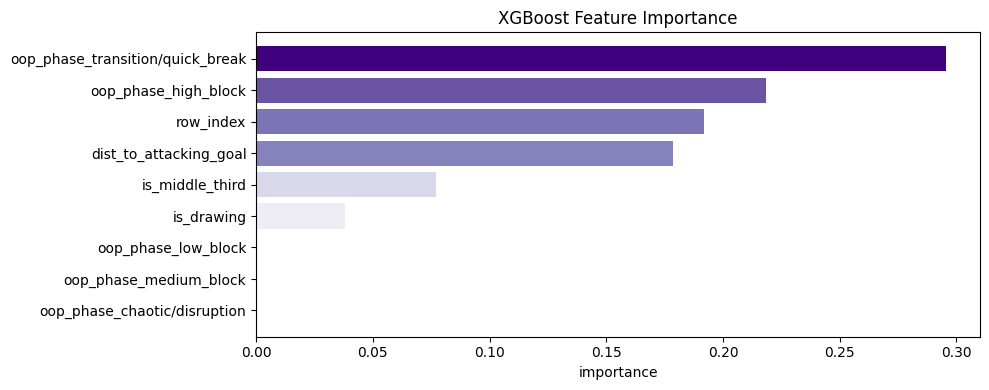

In [103]:
best_xgb = xgb_grid.best_estimator_

xgb_importance = pd.DataFrame({
    "feature": X_test.columns,
    "importance": best_xgb.feature_importances_
}).sort_values("importance", ascending=False)

plot_gradient_bars(xgb_importance, "importance", "XGBoost Feature Importance", cmap="Purples")



C:\Users\navee\AppData\Local\Temp\ipykernel_30860\796877662.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap)(norm)


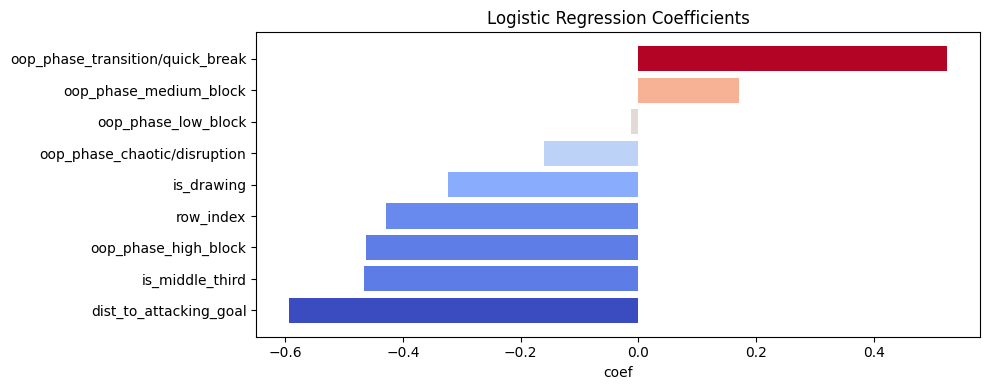

In [104]:
coefs = best_log_reg.named_steps["clf"].coef_[0]

logreg_importance = pd.DataFrame({
    "feature": X_test.columns,
    "coef": coefs
}).sort_values("coef", ascending=False)

plot_gradient_bars(
    logreg_importance,
    "coef",
    "Logistic Regression Coefficients",
    cmap="coolwarm"
)


In [105]:
X_test

,dist_to_attacking_goal,is_drawing,is_middle_third,oop_phase_chaotic/disruption,oop_phase_high_block,oop_phase_low_block,oop_phase_medium_block,oop_phase_transition/quick_break,row_index
0,99.575170,1,0,False,True,False,False,False,0
3,34.427403,1,0,True,False,False,False,False,3
14,51.188596,1,1,True,False,False,False,False,14
19,47.054798,1,1,True,False,False,False,False,19
20,72.213891,1,1,False,False,False,True,False,20
...,...,...,...,...,...,...,...,...,...
5357,73.374887,0,0,True,False,False,False,False,5357
5359,46.164589,0,1,True,False,False,False,False,5359
5362,39.101266,0,0,True,False,False,False,False,5362
5365,82.264328,0,0,True,False,False,False,False,5365


In [106]:
og_df

,Unique ID,match_id,event_index,frame_start,frame_end,rec_player_id,rec_team_short,rec_team_id,dist_to_attacking_goal,team_out_of_possession_phase_type,player_targeted_dangerous,event_row_index,source_file,is_drawing,is_middle_third,row_index
0,1886347_42_46,1886347.0,42.0,387.0,430.0,735578.0,Newcastle,1805.0,99.575170,high_block,0.0,0,1886347.0,1,0,0
3,1886347_170_193,1886347.0,170.0,1492.0,1492.0,735574.0,Newcastle,1805.0,34.427403,chaotic/disruption,0.0,3,1886347.0,1,0,3
14,1886347_452_466,1886347.0,452.0,3799.0,3799.0,50978.0,Newcastle,1805.0,51.188596,chaotic/disruption,1.0,14,1886347.0,1,1,14
19,1886347_452_466,1886347.0,466.0,3854.0,3866.0,38673.0,Auckland FC,4177.0,47.054798,chaotic/disruption,1.0,19,1886347.0,1,1,19
20,1886347_536_558,1886347.0,536.0,4452.0,4452.0,795507.0,Newcastle,1805.0,72.213891,medium_block,1.0,20,1886347.0,1,1,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5837,2017461_2727_2727,2017461.0,2727.0,49727.0,49741.0,38673.0,Auckland FC,4177.0,61.517225,chaotic/disruption,0.0,5837,2017461.0,1,1,5837
5838,2017461_2734_2734,2017461.0,2734.0,49759.0,49759.0,811820.0,Melbourne V FC,868.0,42.788799,chaotic/disruption,0.0,5838,2017461.0,1,0,5838
5841,2017461_3125_3125,2017461.0,3125.0,55073.0,55073.0,43829.0,Auckland FC,4177.0,34.902498,chaotic/disruption,0.0,5841,2017461.0,0,0,5841
5848,2017461_3660_3660,2017461.0,3660.0,63518.0,63527.0,38673.0,Auckland FC,4177.0,78.036013,chaotic/disruption,0.0,5848,2017461.0,0,0,5848


In [107]:
pred_class = best_log_reg.predict(X_test)
pred_prob = best_log_reg.predict_proba(X_test)[:, 1]

X_test_df = pd.DataFrame(X_test, index=X_test.index, columns=X.columns)

X_test_df = X_test_df.reset_index().rename(columns={'index':'row_index'})


# Build a results dataframe
results = pd.DataFrame({
    "row_index": row_test.values,
    "true_value": y_test.values,
    "predicted_class": pred_class,
    "predicted_probability": pred_prob
})

full_results = results.merge(
    og_df, 
    left_on="row_index", 
    right_on="row_index",
    how="inner"
)

full_results.to_csv('../../Our Datasets/classifier_results_logreg.csv', index=False)


In [108]:
full_results

,row_index,true_value,predicted_class,predicted_probability,Unique ID,match_id,event_index,frame_start,frame_end,rec_player_id,rec_team_short,rec_team_id,dist_to_attacking_goal,team_out_of_possession_phase_type,player_targeted_dangerous,event_row_index,source_file,is_drawing,is_middle_third
0,0,0,0,0.196989,1886347_42_46,1886347.0,42.0,387.0,430.0,735578.0,Newcastle,1805.0,99.575170,high_block,0.0,0,1886347.0,1,0
1,3,0,1,0.818607,1886347_170_193,1886347.0,170.0,1492.0,1492.0,735574.0,Newcastle,1805.0,34.427403,chaotic/disruption,0.0,3,1886347.0,1,0
2,14,1,1,0.524581,1886347_452_466,1886347.0,452.0,3799.0,3799.0,50978.0,Newcastle,1805.0,51.188596,chaotic/disruption,1.0,14,1886347.0,1,1
3,19,1,1,0.553058,1886347_452_466,1886347.0,466.0,3854.0,3866.0,38673.0,Auckland FC,4177.0,47.054798,chaotic/disruption,1.0,19,1886347.0,1,1
4,20,1,1,0.555331,1886347_536_558,1886347.0,536.0,4452.0,4452.0,795507.0,Newcastle,1805.0,72.213891,medium_block,1.0,20,1886347.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,5357,0,0,0.361377,1899585_3944_3944,1899585.0,3944.0,51294.0,51308.0,23909.0,Wellington P FC,867.0,73.374887,chaotic/disruption,0.0,5357,1899585.0,0,0
118,5359,0,0,0.323110,1899585_4022_4022,1899585.0,4022.0,51826.0,51837.0,23418.0,Auckland FC,4177.0,46.164589,chaotic/disruption,0.0,5359,1899585.0,0,1
119,5362,0,1,0.596813,1899585_4066_4066,1899585.0,4066.0,52781.0,52781.0,23418.0,Auckland FC,4177.0,39.101266,chaotic/disruption,0.0,5362,1899585.0,0,0
120,5365,0,0,0.305413,1899585_4235_4235,1899585.0,4235.0,54418.0,54426.0,799091.0,Wellington P FC,867.0,82.264328,chaotic/disruption,0.0,5365,1899585.0,0,0
